In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [3]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

df = pd.DataFrame(lista_alumnos, columns=["Nombre", "Edad", "Altura"])

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nombre  21 non-null     str    
 1   Edad    21 non-null     int64  
 2   Altura  21 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 636.0 bytes


In [5]:
df[["Edad", "Altura"]].describe()

,Edad,Altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


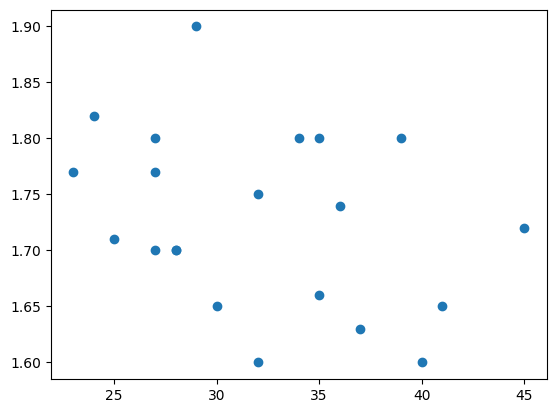

In [6]:
plt.scatter(df["Edad"], df["Altura"])
plt.show()

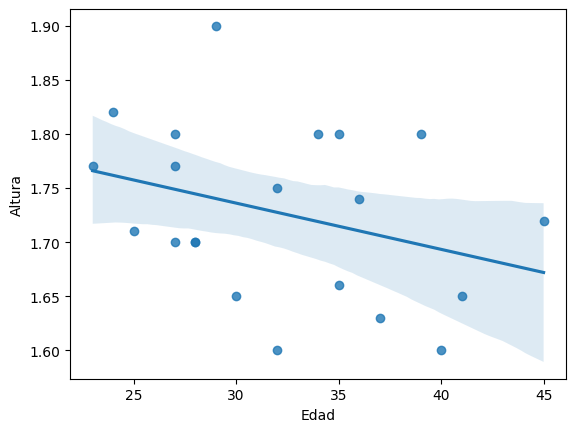

In [7]:
sns.regplot(x="Edad", y="Altura", data=df)
plt.show()

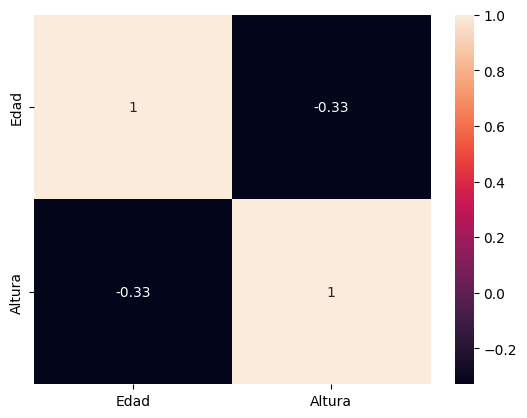

In [8]:
sns.heatmap(df[["Edad", "Altura"]].corr(), annot=True)
plt.show()

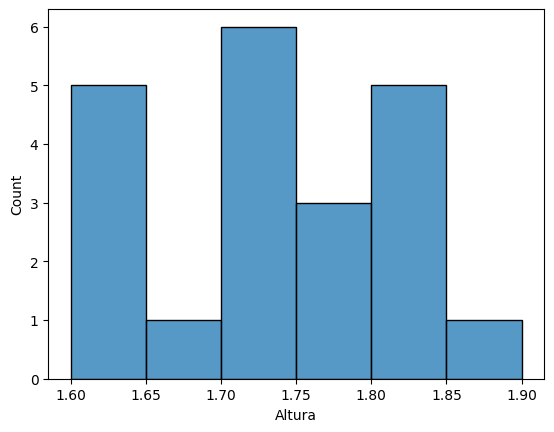

In [9]:
sns.histplot(df["Altura"])
plt.show()

### Entrena un modelo de regresión lineal

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[["Edad"]]
y = df["Altura"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16, 1)
(5, 1)
(16,)
(5,)


y = a + b*x

altura = a + b*Edad

In [13]:
modelo = LinearRegression()

In [14]:
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
modelo.intercept_

np.float64(1.858051298091961)

In [16]:
modelo.coef_

array([-0.00435721])

Altura = 1.86 - 0.004 * Edad

In [17]:
# Predicción para la edad media (32)
print(modelo.predict([[32]])[0])

1.7186205817954332


C:\Users\jvazq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
# Predicciones sobre el conjunto de test
modelo.predict(X_test.values)

C:\Users\jvazq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.75347826, 1.70990616, 1.71862058, 1.74912105, 1.70119174])

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [19]:
y_pred_test = modelo.predict(X_test)
y_pred_test

array([1.75347826, 1.70990616, 1.71862058, 1.74912105, 1.70119174])

In [20]:
y_test

0     1.82
17    1.80
15    1.75
1     1.71
8     1.74
Name: Altura, dtype: float64

In [21]:
# DataFrame con errores del modelo lineal
df_errores = pd.DataFrame({
    "Edad": X_test["Edad"].values,
    "prediccion": y_pred_test,
    "valor_real": y_test.values,
    "error": abs(y_test.values - y_pred_test),
    "error_cuad": (y_test.values - y_pred_test) ** 2
}, index=y_test.index)
df_errores

,Edad,prediccion,valor_real,error,error_cuad
0,24,1.753478,1.82,0.066522,0.004425
17,34,1.709906,1.80,0.090094,0.008117
15,32,1.718621,1.75,0.031379,0.000985
1,25,1.749121,1.71,0.039121,0.001530
8,36,1.701192,1.74,0.038808,0.001506


In [22]:
# MAE manual
df_errores["error"].mean()

np.float64(0.05318486080700664)

In [23]:
# MSE manual
df_errores["error_cuad"].mean()

np.float64(0.0033126493607306537)

In [24]:
# RMSE manual
np.sqrt(df_errores["error_cuad"].mean())

np.float64(0.057555619714591326)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

print("MAE", mean_absolute_error(y_test, y_pred_test))
print("MSE", mean_squared_error(y_test, y_pred_test))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("MAPE", mean_absolute_percentage_error(y_test, y_pred_test))
print("r2_score", r2_score(y_test, y_pred_test))

MAE 0.05318486080700664
MSE 0.0033126493607306537
RMSE 0.057555619714591326
MAPE 0.029943007687355166
r2_score -1.0398087196617292


In [26]:
# DataFrame con errores del modelo naive (media)
y_pred_naive = np.full(len(y_test), df["Altura"].mean())

df_errores_naive = pd.DataFrame({
    "Edad": X_test["Edad"].values,
    "prediccion": np.round(y_pred_naive, 2),
    "valor_real": y_test.values,
    "error": abs(np.round(y_test.values - y_pred_naive, 2)),
    "error_cuad": np.round((y_test.values - y_pred_naive) ** 2, 4)
}, index=y_test.index)
df_errores_naive

,Edad,prediccion,valor_real,error,error_cuad
0,24,1.73,1.82,0.09,0.0086
17,34,1.73,1.80,0.07,0.0053
15,32,1.73,1.75,0.02,0.0005
1,25,1.73,1.71,0.02,0.0003
8,36,1.73,1.74,0.01,0.0002


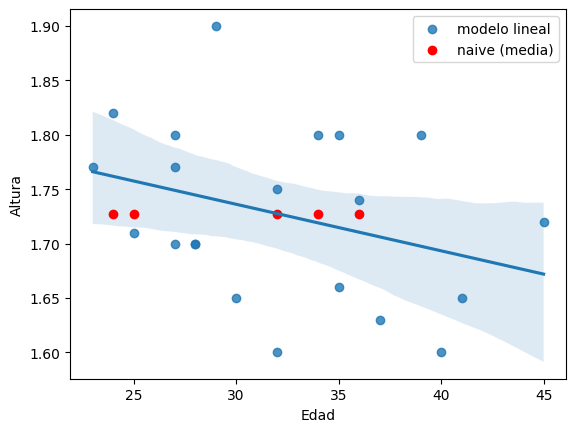

In [27]:
# Comparación visual: modelo lineal vs naive
sns.regplot(x="Edad", y="Altura", data=df, label="modelo lineal")
plt.scatter(X_test["Edad"], y_pred_naive, color="red", label="naive (media)")
plt.legend()
plt.show()

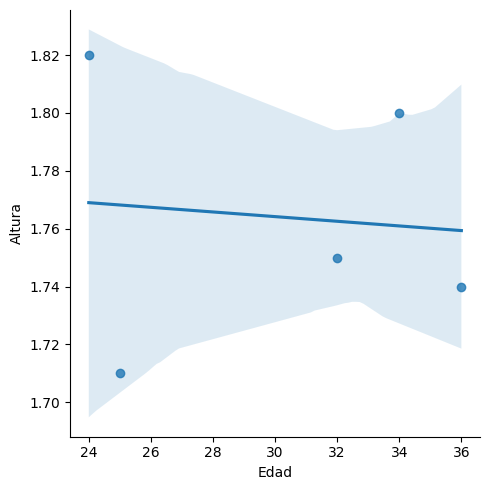

In [28]:
# Regplot solo sobre el conjunto de test
sns.lmplot(x="Edad", y="Altura", data=df[df.index.isin(y_test.index)], height=5, aspect=1)
plt.show()